# Act 1 · Does graphene have a gap?

Kane and Mele (2005) predicted that spin–orbit coupling opens a tiny gap at the Dirac points of graphene and makes
it a quantum spin Hall insulator, with a spin Hall conductivity of exactly e/2π. The gap is a few tens of μeV, far
too small for brute-force k-point sampling. Here you get it from two Wannier functions built on seven k-points,
switch spin–orbit coupling on and off at will, and compute the spin Hall conductivity. About 1 minute of compute.

**Before you start**, in this folder (10 s on 4 cores):
```
mpirun -np 4 python 1_dft.py
```
Then run the cells from top to bottom. Each step says what you should see (**checkpoint**). **Try it** cells are
small optional experiments that take seconds; the two **bonus** steps at the end are for later.

In [1]:
import inspect
import logging
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
from gpaw import GPAW
from irrep.spacegroup import SpaceGroup

import wannierberri as wb
from wannierberri.parallel import ray_init
from wannierberri.symmetry.projections import Projection, ProjectionsSet

if "altermagnetic" not in inspect.signature(wb.WannierDataSOC.from_gpaw).parameters:
    raise ImportError(f"this kernel ({sys.prefix}) has WannierBerri {wb.__version__}, the notebook needs master with "
                      "the fixes in patches/: run  bash setup/install_wannierberri.sh  there, or switch the kernel")

warnings.simplefilter("ignore", UserWarning)  # keep the live output readable
logging.basicConfig(level=logging.WARNING, format="%(message)s", stream=sys.stdout)
logging.getLogger("wannierberri.wannierisation").setLevel(logging.INFO)
os.makedirs("wannier", exist_ok=True)
os.makedirs("results", exist_ok=True)
np.random.seed(0)  # the Wannierisation draws random numbers: fix them for reproducible output

## Step 1 · Symmetry

`irrep` finds the space group from the atoms (and magnetic moments) of the GPAW run.
The NSCF run holds only the irreducible k-points of the 6×6×1 grid.

**Checkpoint:** 48 operations (P6/mmm with time reversal), 7 irreducible k-points.

In [2]:
calc = GPAW("gpaw/nscf.gpw", txt=None)
EF = calc.get_fermi_level()
sg = SpaceGroup.from_gpaw(calc)
print(f"space group {sg.name}: {sg.size} operations (with time reversal)")
print(f"{len(calc.get_ibz_k_points())} irreducible k-points of the 6x6x1 grid (36 points)")

space group P6/mmm1': 48 operations (with time reversal)
7 irreducible k-points of the 6x6x1 grid (36 points)


## Step 2 · Symmetry-adapted Wannier functions

One $p_z$ orbital on each carbon atom. `from_gpaw` computes the overlaps $M_{mn}(\mathbf k,\mathbf b)$,
the projections $A_{mn}(\mathbf k)$, the symmetry matrices $D(g)$ and the SOC matrix elements
straight from the GPAW wave functions. No Wannier90 files are involved.

In [3]:
pz = Projection(position_num=[[1 / 3, 2 / 3, 0], [2 / 3, 1 / 3, 0]], orbital="pz", spacegroup=sg)
wandata = wb.WannierDataSOC.from_gpaw(calc, projections=ProjectionsSet([pz]),
                                      seedname="wannier/graphene")

mpgrid = [6 6 1], 7
mpgrid = [6 6 1], 7


Disentanglement and localisation run on the 7 irreducible k-points only;
`sitesym=True` keeps each Wannier function a proper $p_z$ orbital under all 48 operations.

* Frozen window $[E_F-2.9, E_F+2.8]$ eV: every state inside it is kept exactly, including the Dirac point.
  It stops just above the top of the σ bands at Γ ($E_F-3.0$ eV) and just below the first
  nearly-free-electron state at Γ ($E_F+3.2$ eV), so on each k-point it holds at most the two π states.
* `frozen_states={0: [1]}`: at Γ (k-point 0) the bonding π state is band 1, at $E_F-7.7$ eV: between the lowest
  σ band ($E_F-19.6$ eV) and the upper σ pair, outside the window. Freezing it by index keeps it in the model.

**Checkpoint:** after 100 iterations (a few seconds) both functions have a spread of 0.91 Å².

In [4]:
wandata.wannierise(froz_min=EF - 2.9, froz_max=EF + 2.8, frozen_states={0: [1]},
                   num_iter=100, print_progress_every=50, sitesym=True)

Using the Wannier centers from the projections as initial guess


####################################################################################################


starting WFs


----------------------------------------------------------------------------------------------------


wannier centers and spreads


...

####################################################################################################


time for creating wannierizer 0.5994758605957031


time for iterations 2.3296399116516113


time for updating 2.219019889831543


total time for wannierization 2.9493281841278076


## Step 3 · Tight-binding model and bands

`SystemSOC` stores $H(\mathbf R)$ and the Berry connection $A(\mathbf R)$ for the scalar-relativistic
model, plus the SOC matrix elements $\Delta V^{c}(\mathbf R)$, $c=x,y,z$, projected from the PAW spheres.

**Checkpoint:** the blue bands follow the grey DFT points inside the frozen window.

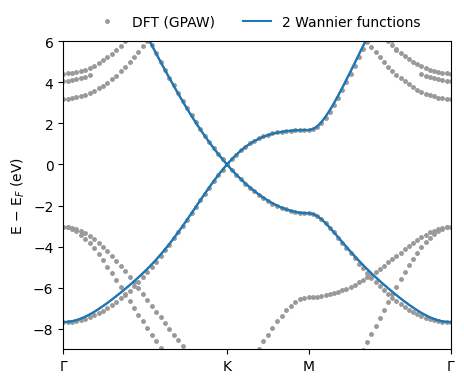

In [5]:
system = wb.SystemSOC.from_wannierdata(wandata, berry=True)
system.set_soc_axis(alpha_soc=0)  # SOC switched off

bs = GPAW("gpaw/bands.gpw", txt=None).band_structure()
x, X, labels = bs.path.get_linear_kpoint_axis()
bands = wb.evaluate_k_path(system, path=wb.Path(system, k_list=bs.path.kpts))
E_dft, E_wann = bs.energies[0] - EF, bands.get_eigenvalues() - EF

fig, ax = plt.subplots(figsize=(5, 4))
dft = ax.plot(x, E_dft, "o", ms=2.5, color="0.6")
wannier = ax.plot(x, E_wann, color="C0", lw=1.5)
ax.legend([dft[0], wannier[0]], ["DFT (GPAW)", "2 Wannier functions"],   # one entry per set of bands
          loc="lower center", bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)
ax.set_xticks(X, ["Γ" if name == "G" else name for name in labels])
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-9, 6)
ax.set_ylabel("E − E$_F$ (eV)")
np.savez("results/graphene_bands.npz", x=x, X=X, labels=labels, E_dft=E_dft, E_wann=E_wann)

## Step 4 · SOC on demand

$$H(\mathbf k) = H_0(\mathbf k)\otimes\mathbb 1 + \alpha \sum_{c} \Delta V^{c}(\mathbf k)\otimes\sigma^{c}(\hat{\mathbf n})$$
The spin axis $\hat{\mathbf n}$ and the scale $\alpha$ are parameters of the model; no new DFT run.
The splitting at K is tens of μeV, so we resolve it with a tiny degeneracy threshold.

**Checkpoint:** no gap for α = 0, 35.8 μeV for α = 1.

In [6]:
K = [1 / 3, 1 / 3, 0]
energy = wb.calculators.tabulate.Energy(degen_thresh=1e-8)
for alpha in [0, 1]:
    system.set_soc_axis(alpha_soc=alpha)
    E = wb.evaluate_k(system, k=K, calculators={"E": energy}).data[0] - EF
    print(f"alpha = {alpha}:  E(K) - EF = {np.round(E * 1e6, 1)} ueV,  gap = {(E[2] - E[1]) * 1e6:.1f} ueV")

alpha = 0:  E(K) - EF = [28.6 28.6 28.6 28.6] ueV,  gap = 0.0 ueV
alpha = 1:  E(K) - EF = [10.7 10.7 46.5 46.5] ueV,  gap = 35.8 ueV


The Dirac point sits 28.6 μeV above GPAW's Fermi level $E_F^0$ (Fermi–Dirac smearing on a 6×6 grid). With α = 1 the gap
spans 10.7–46.5 μeV, so $E_F^0$ lies just below it: the charge-neutral filling (two bands full), not $E_F^0$, is what
puts the Fermi level in the gap. On the meV scale of the α = 1000 plots below the offset is invisible.

Reference: full second-variation SOC in GPAW (all 20 bands). The difference to the Wannier model is SOC at second
order, through bands outside the two-function subspace. The absolute value is sensitive to the plane-wave cutoff
and to the carbon PAW dataset (optional checks in `03_checks/`); the measured gap is 42.2 μeV (Sichau et al. 2019).

**Checkpoint:** GPAW gives 38.7 μeV.

In [7]:
from gpaw.spinorbit import soc_eigenstates

iK = np.argmin(np.linalg.norm(calc.get_ibz_k_points() - K, axis=1))
E_gpaw = soc_eigenstates(calc).eigenvalues()[iK] - EF
E_gpaw = E_gpaw[np.abs(E_gpaw) < 1e-3]
print(f"GPAW:  E(K) - EF = {np.round(E_gpaw * 1e6, 1)} ueV,  gap = {(E_gpaw[2] - E_gpaw[1]) * 1e6:.1f} ueV")

GPAW:  E(K) - EF = [ 9.   9.  47.7 47.7] ueV,  gap = 38.7 ueV


Zoom into the Dirac cone at K (±150 μeV) and switch SOC on step by step, α = 0 … 1: one `set_soc_axis` call per
step. The gap grows linearly with α, since SOC enters to first order.

**Checkpoint:** 7.2 μeV more for every 0.2 in α.

gap at K:  alpha = 0.0:  0.0 ueV,  alpha = 0.2:  7.2 ueV,  alpha = 0.4: 14.3 ueV,  alpha = 0.6: 21.5 ueV,  alpha = 0.8: 28.6 ueV,  alpha = 1.0: 35.8 ueV


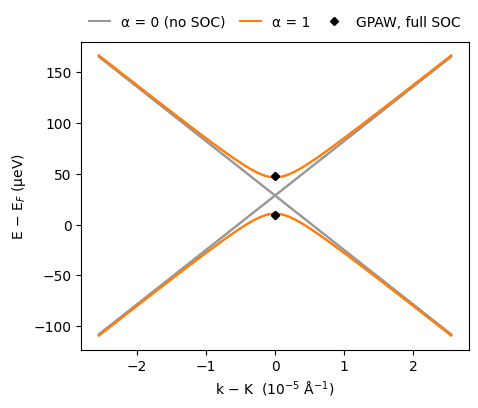

In [8]:
dk = np.array([5e-6, 5e-6, 0])
path_K = wb.Path.from_nodes(system, nodes=[np.array(K) - dk, K, np.array(K) + dk], nk=[61, 61])
k_cart = (path_K.K_list - K) @ system.recip_lattice
k_line = np.sign(k_cart[:, 0]) * np.linalg.norm(k_cart, axis=1)
iK = np.argmin(np.abs(k_line))

alphas = np.linspace(0, 1, 11)
zoom = []
for alpha in alphas:
    system.set_soc_axis(alpha_soc=alpha)
    tab = wb.evaluate_k_path(system, path=path_K, tabulators={"Energy": energy})
    zoom.append(tab.get_eigenvalues() - EF)
zoom = np.array(zoom)
gaps = (zoom[:, iK, 2] - zoom[:, iK, 1]) * 1e6
print("gap at K:  " + ",  ".join(f"alpha = {a:.1f}: {g:4.1f} ueV" for a, g in zip(alphas[::2], gaps[::2])))

fig, ax = plt.subplots(figsize=(5, 4))
no_soc = ax.plot(k_line * 1e5, zoom[0] * 1e6, color="0.6")
soc = ax.plot(k_line * 1e5, zoom[-1] * 1e6, color="C1")
gpaw = ax.plot(np.zeros(len(E_gpaw)), E_gpaw * 1e6, "kD", ms=4)
ax.legend([no_soc[0], soc[0], gpaw[0]], ["α = 0 (no SOC)", "α = 1", "GPAW, full SOC"],   # one entry per set of bands
          loc="lower center", bbox_to_anchor=(0.5, 1), ncol=3, frameon=False, handlelength=1.5, columnspacing=1)
ax.set_xlabel("k − K  (10$^{-5}$ Å$^{-1}$)")
ax.set_ylabel("E − E$_F$ (μeV)")
np.savez("results/graphene_gap.npz", k=k_line, E0=zoom[0], E1=zoom[-1], E_gpaw=E_gpaw,
         alpha=alphas, E_alpha=zoom)

**Try it.** Graphene is not magnetic. Does the gap depend on the direction of the spin axis? Predict, then run.

In [9]:
for theta in (0, 45, 90):
    system.set_soc_axis(theta=theta, phi=0, alpha_soc=1, units="degrees")
    E = wb.evaluate_k(system, k=K, calculators={"E": energy}).data[0] - EF
    print(f"spin axis {theta:2d} deg from z:  gap at K = {(E[2] - E[1]) * 1e6:.1f} ueV")
system.set_soc_axis(alpha_soc=1)

spin axis  0 deg from z:  gap at K = 35.8 ueV


spin axis 45 deg from z:  gap at K = 35.8 ueV


spin axis 90 deg from z:  gap at K = 35.8 ueV


## Step 5 · Spin Hall conductivity

$\sigma^{s_z}_{xy}$ from the spin Berry curvature (Fermi sea, tetrahedron method), with spin current $\{\sigma_z, v_x\}/2$
and spin $s_z=\tfrac{\hbar}{2}\sigma_z$. WannierBerri returns (ħ/e)·S/m; times the layer period and divided by $e^2/h$
this is σ in units of $(\hbar/e)(e^2/h) = e/2\pi$. A quantum spin Hall state gives $(C_\uparrow - C_\downarrow)/2 = 1$ (Kane and Mele's $e/2\pi$).
`external_terms=False` drops the Wannier position matrix elements beyond the centres; `03_checks/` shows that the plateau does not change.
The real gap (36 μeV) would need ~10⁶ k-points per direction, so we scale SOC by α = 1000
(gap ≈ 36 meV). The plateau inside the gap does not depend on α. The 1200×1200 grid
is a multiple of the 6×6 Wannier grid, so Γ, K and M are on it.

**Checkpoint:** a flat plateau at 1.0003 e/2π inside the gap (about 30 s).

2026-09-27 14:52:38,915	INFO worker.py:1852 -- Started a local Ray instance.


(raylet) [2026-09-27 14:52:48,875 E 11003 26281004] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-09-27_14-52-37_583757_10887 is over 95% full, available space: 7.81254 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.


(raylet) [2026-09-27 14:52:58,902 E 11003 26281004] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-09-27_14-52-37_583757_10887 is over 95% full, available space: 7.8103 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.


(raylet) [2026-09-27 14:53:08,915 E 11003 26281004] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-09-27_14-52-37_583757_10887 is over 95% full, available space: 7.80659 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.


(raylet) [2026-09-27 14:53:18,989 E 11003 26281004] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-09-27_14-52-37_583757_10887 is over 95% full, available space: 6.80666 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.


(raylet) [2026-09-27 14:53:29,017 E 11003 26281004] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2026-09-27_14-52-37_583757_10887 is over 95% full, available space: 6.80514 GB; capacity: 460.432 GB. Object creation will fail if spilling is required.


sigma^z_xy(E_F) = 1.0003 e/2pi  (alpha = 1000)


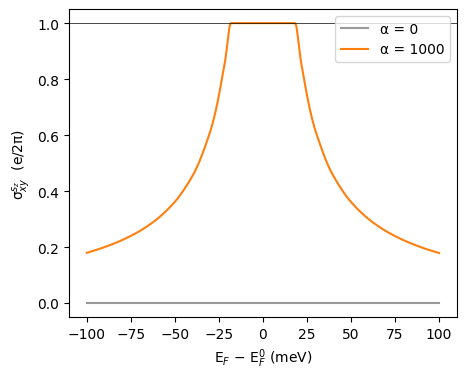

In [10]:
try:
    ray_init()   # k-points in parallel on all cores
except ImportError:
    print("Ray is not installed: running in serial, several times slower")
Efermi = np.linspace(EF - 0.1, EF + 0.1, 401)
shc = wb.calculators.static.SHC(Efermi=Efermi, tetra=True,
                                kwargs_formula={"spin_current_type": "simple", "external_terms": False})
e2h = 3.874045865e-5                    # e^2/h in S
c = system.real_lattice[2, 2] * 1e-10   # layer period in m: S/m -> S per layer

sigma = {}
for alpha in [0, 1000]:
    system.set_soc_axis(alpha_soc=alpha)
    result = wb.run(system, grid=wb.Grid(system, NK=(1200, 1200, 1)), calculators={"shc": shc},
                    fout_name="wannier/graphene", print_progress_step_time=60)
    sigma[alpha] = result.results["shc"].data[:, 0, 1, 2] * c / e2h
i0 = np.argmin(np.abs(Efermi - EF))
print(f"sigma^z_xy(E_F) = {sigma[1000][i0]:.4f} e/2pi  (alpha = 1000)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot((Efermi - EF) * 1e3, sigma[0], color="0.6", label="α = 0")
ax.plot((Efermi - EF) * 1e3, sigma[1000], color="C1", label="α = 1000")
ax.axhline(1, color="k", lw=0.5)
ax.set_xlabel("E$_F$ − E$_F^{0}$ (meV)")
ax.set_ylabel("σ$^{s_z}_{xy}$  (e/2π)")
ax.legend()
np.savez("results/graphene_shc.npz", E=Efermi - EF, sigma0=sigma[0], sigma1000=sigma[1000])

**Try it.** Is the plateau converged? Halve the grid (a few seconds) and compare.

In [11]:
result = wb.run(system, grid=wb.Grid(system, NK=(600, 600, 1)), calculators={"shc": shc},
                fout_name="wannier/graphene", print_progress_step_time=60)
sigma_600 = result.results["shc"].data[:, 0, 1, 2] * c / e2h
print(f"600 x 600: {sigma_600[i0]:.4f} e/2pi,  1200 x 1200: {sigma[1000][i0]:.4f} e/2pi")

600 x 600: 1.0447 e/2pi,  1200 x 1200: 1.0003 e/2pi


## Bonus 6 · The Wannier SOC matrix is the Kane–Mele model

Group the hoppings $H_{ij}(\mathbf R)$ and the SOC matrix elements $\Delta V^{c}_{ij}(\mathbf R)$ by distance.
The $\sigma_h$ mirror of flat graphene forbids $\Delta V^{x}$ and $\Delta V^{y}$ (no Rashba term), so $s_z$ is conserved.
What is left is an imaginary next-nearest-neighbour hopping $i\lambda\nu_{ij}s_z$, the Kane–Mele term,
which opens a gap $6\sqrt3\,\lambda$ at K. The second cell checks the two defining properties: the elements are
purely imaginary, and their sign alternates with the bond direction ($\nu_{ij}=\pm1$) and is opposite on the two sublattices.

In [12]:
up = system.system_up
H, dV, iR = up.get_R_mat("Ham"), up.get_R_mat("dV_soc"), up.rvec.iRvec
wcc, lattice = up.wannier_centers_cart, up.real_lattice
shells = {}
for r, R in enumerate(iR):
    for i in range(2):
        for j in range(2):
            d = round(float(np.linalg.norm(R @ lattice + wcc[j] - wcc[i])), 2)
            t, v = shells.get(d, (0.0, np.zeros(3)))
            shells[d] = (max(t, abs(H[r, i, j])), np.maximum(v, np.abs(dV[r, i, j])))
dist = sorted(shells)[:7]
print(" |d| (A)   max|t| (eV)   max |dV^x|, |dV^y|, |dV^z| (ueV)")
for d in dist:
    print(f"{d:7.2f} {shells[d][0]:12.3f}   {np.round(shells[d][1] * 1e6, 3)}")
lam = shells[2.46][1][2]
print(f"lambda = {lam * 1e6:.2f} ueV  ->  6 sqrt(3) lambda = {6 * np.sqrt(3) * lam * 1e6:.1f} ueV")
np.savez("results/graphene_km.npz", d=dist, t=[shells[d][0] for d in dist], dV=[shells[d][1] for d in dist])

 |d| (A)   max|t| (eV)   max |dV^x|, |dV^y|, |dV^z| (ueV)
   0.00        1.486   [0. 0. 0.]
   1.42        2.899   [0. 0. 0.]
   2.46        0.246   [0.    0.    3.437]
   2.84        0.263   [0. 0. 0.]
   3.76        0.018   [0. 0. 0.]
   4.26        0.042   [0. 0. 0.]
   4.92        0.027   [0.    0.    0.262]
lambda = 3.44 ueV  ->  6 sqrt(3) lambda = 35.7 ueV


In [13]:
print("sublattice  bond angle   Re dV^z (ueV)   Im dV^z (ueV)   next-nearest neighbours only")
nnn = []
for r, R in enumerate(iR):
    d = R @ lattice                      # same sublattice: the Wannier centres cancel
    if abs(np.linalg.norm(d) - lattice[0, 0]) < 1e-3:
        for i in range(2):
            nnn.append(("AB"[i], np.degrees(np.arctan2(d[1], d[0])) % 360, dV[r, i, i, 2]))
for sub, angle, v in sorted(nnn):
    print(f"    {sub}        {angle:5.0f}      {v.real * 1e6:+10.2e}      {v.imag * 1e6:+8.3f}")

sublattice  bond angle   Re dV^z (ueV)   Im dV^z (ueV)   next-nearest neighbours only
    A            0       +0.00e+00        +3.437
    A           60       +0.00e+00        -3.437
    A          120       +0.00e+00        +3.437
    A          180       +0.00e+00        -3.437
    A          240       +0.00e+00        +3.437
    A          300       +0.00e+00        -3.437
    B            0       +0.00e+00        -3.437
    B           60       +0.00e+00        +3.437
    B          120       +0.00e+00        -3.437
    B          180       +0.00e+00        +3.437
    B          240       +0.00e+00        -3.437
    B          300       +0.00e+00        +3.437


## Bonus 7 · Converging the plateau, and the plateau at the real gap

Inside the gap every state is either full or empty, so the tetrahedron method and a plain k-sum agree.
What matters is resolving the Berry-curvature peak at K, whose width is about $\Delta/\hbar v_F \approx 0.006$ Å⁻¹.

In [14]:
system.set_soc_axis(alpha_soc=1000)
shc_EF = wb.calculators.static.SHC(Efermi=np.array([EF]),
                                   kwargs_formula={"spin_current_type": "simple", "external_terms": False})
b = np.linalg.norm(system.recip_lattice[0])
nks = [150, 300, 600, 1200]
sigma_nk = []
for nk in nks:
    result = wb.run(system, grid=wb.Grid(system, NK=(nk, nk, 1)), calculators={"shc": shc_EF},
                    fout_name="wannier/graphene", print_progress_step_time=60)
    sigma_nk.append(result.results["shc"].data[0, 0, 1, 2] * c / e2h)
    print(f"NK = {nk:4d}  (spacing {b / nk:.4f} 1/A):  sigma^z_xy(E_F) = {sigma_nk[-1]:.4f} e/2pi")
np.savez("results/graphene_shc_convergence.npz", nk=nks, spacing=b / np.array(nks), sigma=sigma_nk)

NK =  150  (spacing 0.0197 1/A):  sigma^z_xy(E_F) = 5.0192 e/2pi


NK =  300  (spacing 0.0098 1/A):  sigma^z_xy(E_F) = 1.6604 e/2pi


NK =  600  (spacing 0.0049 1/A):  sigma^z_xy(E_F) = 1.0447 e/2pi


NK = 1200  (spacing 0.0025 1/A):  sigma^z_xy(E_F) = 1.0003 e/2pi


**The real gap.** With α = 1 the curvature peak is 6·10⁻⁶ Å⁻¹ wide, far below any uniform grid. Instead, integrate
the spin Berry curvature on a log-polar grid around K (radii 10⁻¹⁰ … 0.5 Å⁻¹); K′ contributes the same by time reversal:
$$\sigma^{s_z}_{xy} = \frac{e}{2\pi}\,\frac{1}{4\pi}\int_{\rm BZ} d^2k \sum_{n\in{\rm occ}} \tilde\Omega^{\sigma_z}_n(\mathbf k),\qquad
\tilde\Omega^{\sigma_z}_n = -2\,{\rm Im}\sum_{m\ne n}\frac{\langle n|\tfrac12\{\sigma_z, \partial_{k_x}H\}|m\rangle\langle m|\partial_{k_y}H|n\rangle}{(\varepsilon_n-\varepsilon_m)^2}$$
with Pauli $\sigma_z$ and $\partial_{\mathbf k}H$ in eV·Å, so $\tilde\Omega$ is in Å². "Occupied" means the two lower bands: charge neutrality.

In [15]:
B = system.recip_lattice
K_cart = (B[0] + B[1]) / 3
edges = np.concatenate([[0], np.geomspace(1e-10, 0.5, 400)])
r, dr = 0.5 * (edges[1:] + edges[:-1]), np.diff(edges)
angles = (np.arange(48) + 0.5) * 2 * np.pi / 48
rr, aa = np.meshgrid(r, angles, indexing="ij")
k_polar = np.stack([K_cart[0] + (rr * np.cos(aa)).ravel(), K_cart[1] + (rr * np.sin(aa)).ravel(),
                    np.zeros(rr.size)], axis=1)
weight = (rr * dr[:, None] * 2 * np.pi / 48).ravel()
spin_berry = {"Energy": wb.calculators.tabulate.Energy(degen_thresh=1e-12),
              "sb": wb.calculators.tabulate.SpinBerry(degen_thresh=1e-12,
                                                      kwargs_formula={"spin_current_type": "simple",
                                                                      "external_terms": False})}
cumulative = {}
for alpha in [1, 100, 1000]:
    system.set_soc_axis(alpha_soc=alpha)
    omega = []
    for i in range(0, len(k_polar), 500):
        path_k = wb.Path(system, k_list=k_polar[i:i + 500] @ np.linalg.inv(B))
        tab = wb.evaluate_k_path(system, path=path_k, tabulators=spin_berry, parallel=False)
        omega.append(tab.get_data("sb")[:, :2, 0, 1, 2].sum(axis=1))   # two occupied bands
    ring = (weight * np.concatenate(omega)).reshape(rr.shape).sum(axis=1)
    cumulative[alpha] = 2 * np.cumsum(ring) / (4 * np.pi)                # K and K'
    print(f"alpha = {alpha:4d}: sigma^z_xy from |k - K| < 0.5 1/A (and K') = {cumulative[alpha][-1]:.4f} e/2pi")
np.savez("results/graphene_shc_polar.npz", r=edges[1:], **{f"alpha{a}": v for a, v in cumulative.items()})

alpha =    1: sigma^z_xy from |k - K| < 0.5 1/A (and K') = 0.9997 e/2pi


alpha =  100: sigma^z_xy from |k - K| < 0.5 1/A (and K') = 0.9992 e/2pi


alpha = 1000: sigma^z_xy from |k - K| < 0.5 1/A (and K') = 0.9948 e/2pi
